# Explorative Analyse: Arbeitsmarkt Regensburg (Jobcenter) — Teil 2: Analyse & Visualisierung

Baut auf den in [`01_Exploration.ipynb`](01_Exploration.ipynb) exportierten CSV-Dateien
(`Data/processed/eckwerte_long.csv`, `Data/processed/kennzahlen_sgb2.csv`) auf.
Falls diese fehlen, `01_Exploration.ipynb` einmal komplett ausführen.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

PROCESSED_DIR = Path("..") / "Data" / "processed"

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv(PROCESSED_DIR / "eckwerte_long.csv")
df["period"] = pd.PeriodIndex(df["period"], freq="M")

kennzahlen = pd.read_csv(PROCESSED_DIR / "kennzahlen_sgb2.csv", index_col="period", parse_dates=["period"])
kennzahlen = kennzahlen.sort_index()

bestand = kennzahlen["Arbeitslose (Bestand)"]
quote = kennzahlen["Arbeitslosenquote (%)"]
lza = kennzahlen["Langzeitarbeitslose"]
uq = kennzahlen["Unterbeschäftigungsquote (%)"]
bg = kennzahlen["Bedarfsgemeinschaften"]
pers = kennzahlen["Personen in BG"]

kennzahlen

,Arbeitslose (Bestand),Arbeitslosenquote (%),Langzeitarbeitslose,Unterbeschäftigungsquote (%),Bedarfsgemeinschaften,Personen in BG,Regelleistungsberechtigte (RLB),Erwerbsfähige Leistungsberechtigte (ELB),Nicht erwerbsfähige Leistungsberechtigte (NEF)
period,,,,,,,,,
2025-01-01,1470.0,1.3,502.0,1.9,2797.303381,5488.033274,5202.270477,3730.590852,1471.679625
2025-02-01,1382.0,1.2,502.0,1.8,2755.768665,5434.992911,5147.992911,3710.211568,1437.781343
2025-03-01,1414.0,1.2,513.0,1.8,2781.436728,5474.933615,5178.933615,3746.433943,1432.499672
2025-04-01,1457.0,1.3,526.0,1.8,2766.959069,5421.148834,5122.424563,3701.239670,1421.184893
2025-05-01,1438.0,1.2,558.0,1.8,2707.556182,5295.629265,4989.629265,3612.418872,1377.210393
2025-06-01,1509.0,1.3,551.0,1.8,2696.605759,5275.539536,4960.102098,3584.217725,1375.884374
2025-07-01,1475.0,1.3,561.0,1.8,2616.920054,5092.808598,4788.461509,3477.798107,1310.663402
2025-08-01,1587.0,1.4,585.0,1.8,2688.060659,5267.867812,4961.929122,3593.655245,1368.273878
2025-09-01,1585.0,1.4,592.0,1.8,2669.283813,5218.350099,4934.149358,3564.447439,1369.701919


## 1. Übersicht: Kennzahlen im Vergleich

**SGB II** (Zweites Buch Sozialgesetzbuch) regelt die *Grundsicherung für Arbeitsuchende*
(umgangssprachlich „Bürgergeld", vormals „Hartz IV") und wird von den **Jobcentern** verwaltet
— daher der Fokus dieser Analyse auf den „Rechtskreis SGB II". Abzugrenzen ist das vom
**SGB III** (Arbeitslosenversicherung), für das die Agentur für Arbeit zuständig ist und das
Menschen mit Anspruch auf Arbeitslosengeld I betrifft. Die Berichte weisen beide Rechtskreise
getrennt aus; alle Kennzahlen in dieser Analyse beziehen sich — sofern nicht anders angegeben
— ausschließlich auf SGB II.

Die vier wichtigsten Kernkennzahlen in einem Diagramm: **Bedarfsgemeinschaften**-,
**Arbeitslosen**- und **Langzeitarbeitslosen**-Balken überlappend vor der Fläche aller
**Personen in Bedarfsgemeinschaften** im Hintergrund — die Fläche ist immer die größte Menge,
die Balken werden von außen nach innen kleiner (BG → Arbeitslose → Langzeitarbeitslose).
Maus über einen Monat bewegen zeigt alle vier Werte gleichzeitig als Tooltip an (Plotly).

In [2]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=pers.index, y=pers.values, name="Personen in BG (gesamt)",
    mode="lines+markers", fill="tozeroy",
    line=dict(color="#1d4ed8", width=1), fillcolor="rgba(147,197,253,0.3)", marker=dict(size=4),
))

fig.add_trace(go.Bar(x=bg.index, y=bg.values, marker_color="rgba(245,158,11,0.6)", hoverinfo="skip", showlegend=False))
fig.add_trace(go.Scatter(
    x=bg.index, y=bg.values, name="Bedarfsgemeinschaften",
    mode="lines+markers", line=dict(color="#b45309", width=1), marker=dict(size=4),
))

fig.add_trace(go.Bar(x=bestand.index, y=bestand.values, marker_color="#2563eb", hoverinfo="skip", showlegend=False))
fig.add_trace(go.Scatter(
    x=bestand.index, y=bestand.values, name="Arbeitslose (Bestand)",
    mode="lines+markers", line=dict(color="#1e3a8a", width=1), marker=dict(size=4),
))

fig.add_trace(go.Bar(x=lza.index, y=lza.values, marker_color="#7c3aed", hoverinfo="skip", showlegend=False))
fig.add_trace(go.Scatter(
    x=lza.index, y=lza.values, name="Langzeitarbeitslose",
    mode="lines+markers", line=dict(color="#4c1d95", width=1), marker=dict(size=4),
))

fig.update_layout(
    title="Arbeitslose, Langzeitarbeitslose und Bedarfsgemeinschaften im Verhältnis zu allen Personen in BG, Jobcenter Regensburg",
    yaxis_title="Personen / Bedarfsgemeinschaften",
    xaxis_title="Monat",
    barmode="overlay",
    hovermode="x unified",
    height=500,
)
fig

## 2. Arbeitslosen- und Unterbeschäftigungsquote

Beide Werte sind **Anteilswerte**, keine Rohzahlen: Die Arbeitslosenquote setzt den SGB-II-Bestand
ins Verhältnis zu **allen zivilen Erwerbspersonen** Regensburgs (Beschäftigte + Arbeitslose
zusammen — nicht nur die SGB-II-Fälle). Die Unterbeschäftigungsquote nutzt eine etwas breitere
Bezugsgröße, die zusätzlich unterbeschäftigte Personen (z. B. in arbeitsmarktpolitischen
Maßnahmen) mit einschließt — deshalb liegt sie meist etwas über der Arbeitslosenquote, obwohl
beide sich auf denselben Rechtskreis SGB II beziehen.

In [3]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=quote.index, y=quote.values, name="Arbeitslosenquote (SGB II-Anteil)",
    mode="lines+markers", line=dict(color="#2563eb"), marker=dict(symbol="circle", size=6),
))
fig.add_trace(go.Scatter(
    x=uq.index, y=uq.values, name="Unterbeschäftigungsquote (SGB II-Anteil)",
    mode="lines+markers", line=dict(color="#dc2626"), marker=dict(symbol="square", size=6),
))
fig.update_layout(
    title="Arbeitslosen- vs. Unterbeschäftigungsquote",
    yaxis_title="Anteil an den Erwerbspersonen (%)",
    yaxis_ticksuffix="%",
    xaxis_title="Monat",
    hovermode="x unified",
    height=650,
    width=1000,
)
fig

## 3. Langzeitarbeitslosigkeit

Anteil der Langzeitarbeitslosen (≥ 1 Jahr arbeitslos) am gesamten Bestand der Arbeitslosen im
SGB II — die absolute Entwicklung ist bereits in der Übersicht oben enthalten.

In [4]:
lza_anteil = (lza / bestand * 100).round(1)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=lza_anteil.index, y=lza_anteil.values, name="Anteil Langzeitarbeitslose",
    mode="lines+markers", line=dict(color="#7c3aed"), marker=dict(symbol="circle", size=6),
    hovertemplate="%{y}<extra></extra>",
))
fig.update_layout(
    title="Langzeitarbeitslose: Anteil an allen Arbeitslosen (SGB II)",
    yaxis_title="Prozent",
    yaxis_ticksuffix="%",
    xaxis_title="Monat",
    hovermode="x unified",
    showlegend=False,
    height=450,
)
fig.show()

print(f"Langzeitarbeitslose: {lza.iloc[0]:.0f} ({lza.index[0]:%b %Y}) -> {lza.iloc[-1]:.0f} ({lza.index[-1]:%b %Y})")
print(f"Anteil am Bestand: {lza_anteil.iloc[0]:.1f}% -> {lza_anteil.iloc[-1]:.1f}%")

Langzeitarbeitslose: 502 (Jan 2025) -> 709 (Jun 2026)
Anteil am Bestand: 34.1% -> 47.3%


## 4. Kennzahlen im Vergleich (indexiert)

Die vier Kernkennzahlen haben sehr unterschiedliche Größenordnungen (500 bis 5.000+), daher
werden sie hier auf den ersten Berichtsmonat **indexiert**: Der Wert im Startmonat wird gleich
**100** gesetzt, alle folgenden Monate werden relativ dazu umgerechnet.

**So liest man die Werte:** 100 = wie im Startmonat. Ein Wert von **110** bedeutet **+10 %**
gegenüber dem Startmonat, ein Wert von **90** bedeutet **−10 %**. So lassen sich Kennzahlen mit
völlig unterschiedlichen absoluten Größenordnungen (z. B. 700 Langzeitarbeitslose vs. 5.000
Personen in BG) in einem Diagramm vergleichen.

In [5]:
vergleich_spalten = ["Arbeitslose (Bestand)", "Langzeitarbeitslose", "Bedarfsgemeinschaften", "Personen in BG"]
indexiert = (kennzahlen[vergleich_spalten] / kennzahlen[vergleich_spalten].iloc[0] * 100).round(1)

fig = go.Figure()
for spalte in vergleich_spalten:
    fig.add_trace(go.Scatter(
        x=indexiert.index, y=indexiert[spalte], name=spalte,
        mode="lines+markers", marker=dict(size=6),
        hovertemplate="%{y:.1f}<extra></extra>",
    ))
fig.add_hline(y=100, line_dash="dash", line_color="grey", annotation_text="Startmonat = 100 %")
fig.update_layout(
    title=f"Kennzahlen im Vergleich (indexiert, {indexiert.index[0]:%b %Y} = 100 %)",
    yaxis_title="Index (Startmonat = 100 %)",
    yaxis_ticksuffix="%",
    xaxis_title="Monat",
    hovermode="x unified",
    height=500,
)
fig

## 5. Altersstruktur und Geschlecht (letzter Berichtsmonat)

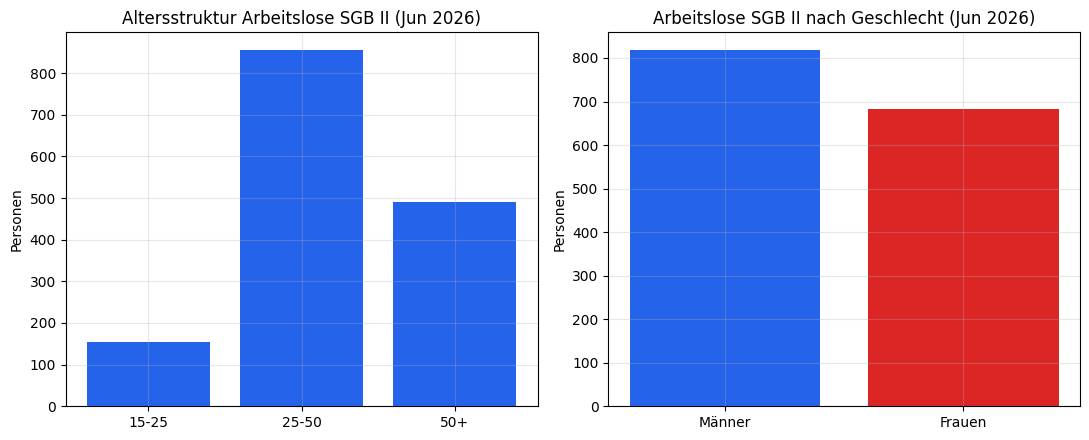

In [6]:
letzter_monat = df["period"].max()
letzter_monat_label = letzter_monat.strftime("%b %Y")
snap = df[(df["period"] == letzter_monat) & (df["kategorie"] == "Arbeitslose")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

alter_labels = ["15 bis unter 25 Jahre", "25 bis unter 50 Jahre", "50 Jahre und älter"]
alter_werte = [snap.set_index("merkmal").loc[l, "sgb2"] for l in alter_labels]
ax1.bar(["15-25", "25-50", "50+"], alter_werte, color="#2563eb")
ax1.set_title(f"Altersstruktur Arbeitslose SGB II ({letzter_monat_label})")
ax1.set_ylabel("Personen")

geschlecht_labels = ["Männer", "Frauen"]
geschlecht_werte = [snap.set_index("merkmal").loc[l, "sgb2"] for l in geschlecht_labels]
ax2.bar(geschlecht_labels, geschlecht_werte, color=["#2563eb", "#dc2626"])
ax2.set_title(f"Arbeitslose SGB II nach Geschlecht ({letzter_monat_label})")
ax2.set_ylabel("Personen")

plt.tight_layout()
plt.show()

## 6. Veränderung zum Vormonat und zum Vorjahresmonat

In [7]:
def veraenderung(series: pd.Series) -> pd.Series:
    letzter = series.iloc[-1]
    vormonat = series.iloc[-2]
    vorjahr = series.iloc[-13] if len(series) >= 13 else None
    return pd.Series({
        "aktuell": letzter,
        "Vormonat abs.": letzter - vormonat,
        "Vormonat %": round((letzter - vormonat) / vormonat * 100, 1),
        "Vorjahresmonat abs.": (letzter - vorjahr) if vorjahr is not None else None,
        "Vorjahresmonat %": round((letzter - vorjahr) / vorjahr * 100, 1) if vorjahr is not None else None,
    })


changes = pd.DataFrame({
    "Arbeitslose (Bestand)": veraenderung(bestand),
    "Langzeitarbeitslose": veraenderung(lza),
    "Bedarfsgemeinschaften": veraenderung(bg),
    "Personen in BG": veraenderung(pers),
}).T
changes

,aktuell,Vormonat abs.,Vormonat %,Vorjahresmonat abs.,Vorjahresmonat %
Arbeitslose (Bestand),1500.000000,-52.000000,-3.4,-9.000000,-0.6
Langzeitarbeitslose,709.000000,-5.000000,-0.7,158.000000,28.7
Bedarfsgemeinschaften,2673.353373,-41.012939,-1.5,-23.252386,-0.9
Personen in BG,5149.986005,-64.836537,-1.2,-125.553531,-2.4


## 7. Zusammenfassung

Auf Basis der 18 Monatsberichte (Januar 2025 – Juni 2026) für das Jobcenter Regensburg (Rechtskreis SGB II):

- **Arbeitslose (Bestand):** von 1.470 (Jan 2025) auf 1.500 (Jun 2026) – leicht gestiegen, mit einem
  Zwischenhoch von 1.587 im August 2025 und einem Tiefpunkt von 1.382 im Februar 2025.
- **Arbeitslosenquote:** schwankt eng zwischen 1,2 % und 1,4 %, aktuell wieder bei 1,3 % – insgesamt stabil.
- **Langzeitarbeitslosigkeit:** deutlichster Trend im Datensatz – von 502 auf 709 Personen (+ rund 41 %),
  mit einem Höchststand von 714 im Mai 2026. Der Anteil an allen Arbeitslosen ist damit von 34,1 % auf
  47,3 % spürbar gestiegen.
- **Bedarfsgemeinschaften / Personen im Leistungsbezug:** beide Kennzahlen sind rückläufig
  (BG: 2.797 → 2.673, ca. −4 %; Personen in BG: 5.488 → 5.150, ca. −6 %).

**Interpretation:** Während die reine Arbeitslosenzahl und -quote im Beobachtungszeitraum relativ stabil
geblieben sind, hat sich die Langzeitarbeitslosigkeit spürbar verschärft – ein Hinweis darauf, dass es für
einen wachsenden Teil der Betroffenen schwerer wird, aus der Arbeitslosigkeit herauszukommen, auch wenn die
Zahl der Bedarfsgemeinschaften insgesamt sinkt.